# День 6 — Инференс и сравнение моделей

Цель: сравнить baseline модель из Дня 4 и fine-tuned DistilBERT
из Дня 5 на одной и той же validation выборке.

Baseline:
text - DistilBERT - CLS embedding - Logistic Regression

Fine-tuned:
text - fine-tuned DistilBERT - classification head

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
)

C:\ProgramData\anaconda3\envs\transformers_overall_clean\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 32

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

data_dir = Path("../data")
models_dir = Path("../models")
outputs_dir = Path("../outputs")

validation_path = (
    data_dir
    / "splits"
    / "validation.csv"
)

fine_tuned_dir = (
    models_dir
    / "fine_tuned_model"
)

baseline_classifier_path = (
    models_dir
    / "baseline"
    / "logistic_regression.joblib"
)

comparison_dir = (
    outputs_dir
    / "comparison"
)

comparison_dir.mkdir(
    parents=True,
    exist_ok=True,
)

print("Device:", device)
print("Validation:", validation_path.resolve())
print("Fine-tuned model:", fine_tuned_dir.resolve())
print("Baseline classifier:", baseline_classifier_path.resolve())
print("Comparison output:", comparison_dir.resolve())

Device: cpu
Validation: C:\Users\User\Projects\transformers_overall_fix\data\splits\validation.csv
Fine-tuned model: C:\Users\User\Projects\transformers_overall_fix\models\fine_tuned_model
Baseline classifier: C:\Users\User\Projects\transformers_overall_fix\models\baseline\logistic_regression.joblib
Comparison output: C:\Users\User\Projects\transformers_overall_fix\outputs\comparison


In [3]:
validation_df = pd.read_csv(
    validation_path
)

print("Validation shape:", validation_df.shape)

print("\nClasses:")
print(
    validation_df["label"]
    .value_counts()
    .sort_index()
)

display(validation_df.head())

assert validation_df.shape == (400, 2)

assert (
    validation_df["label"]
    .value_counts()
    .to_dict()
    == {
        0: 200,
        1: 200,
    }
)

print("Validation data loaded correctly")

Validation shape: (400, 2)

Classes:
label
0    200
1    200
Name: count, dtype: int64


,text,label
0,"stale , standard , connect-the-dots storyline",0
1,feel the wasted potential of this slapstick co...,0
2,"is smart to vary the pitch of his movie , bala...",1
3,watch people doing unpleasant things to each o...,0
4,corny television,0


Validation data loaded correctly


In [4]:
tokenizer_ft = AutoTokenizer.from_pretrained(
    fine_tuned_dir
)

model_ft = (
    AutoModelForSequenceClassification
    .from_pretrained(
        fine_tuned_dir
    )
)

model_ft = model_ft.to(device)
model_ft.eval()

print("Fine-tuned model loaded")
print(
    "Device:",
    next(model_ft.parameters()).device,
)
print(
    "Number of labels:",
    model_ft.config.num_labels,
)

Loading weights: 100%|██████████| 104/104 [00:00<?, ?it/s]

Fine-tuned model loaded
Device: cpu
Number of labels: 2


In [5]:
tokenizer_base = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model_base = AutoModel.from_pretrained(
    MODEL_NAME
)

model_base = model_base.to(device)
model_base.eval()

print("Baseline encoder loaded")
print(
    "Device:",
    next(model_base.parameters()).device,
)

baseline_classifier = joblib.load(
    baseline_classifier_path
)

print("Baseline classifier loaded")
print(
    "Classifier:",
    baseline_classifier.__class__.__name__,
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6429.92it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Baseline encoder loaded
Device: cpu
Baseline classifier loaded
Classifier: LogisticRegression


In [6]:
assert validation_path.exists()
assert fine_tuned_dir.exists()
assert baseline_classifier_path.exists()

assert model_ft.config.num_labels == 2

print("All Day 6 components are ready")

All Day 6 components are ready


In [7]:
def predict_fine_tuned(
    texts,
    model,
    tokenizer,
    device,
    batch_size=32,
):
    if isinstance(texts, str):
        texts = [texts]

    model.eval()

    results = []

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[
            start_idx:start_idx + batch_size
        ]

        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )

        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        with torch.no_grad():
            outputs = model(**inputs)

        probabilities = torch.softmax(
            outputs.logits,
            dim=1,
        )

        predictions = torch.argmax(
            probabilities,
            dim=1,
        )

        probabilities = (
            probabilities
            .cpu()
            .numpy()
        )

        predictions = (
            predictions
            .cpu()
            .numpy()
        )

        for text, prediction, probs in zip(
            batch_texts,
            predictions,
            probabilities,
        ):
            results.append({
                "text": text,
                "prediction": int(prediction),
                "probabilities": probs,
            })

    return results

In [8]:
def predict_baseline(
    texts,
    encoder,
    tokenizer,
    classifier,
    device,
    batch_size=32,
):
    if isinstance(texts, str):
        texts = [texts]

    encoder.eval()

    all_embeddings = []

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[
            start_idx:start_idx + batch_size
        ]

        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )

        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        with torch.no_grad():
            outputs = encoder(**inputs)

        cls_embeddings = (
            outputs
            .last_hidden_state[:, 0, :]
            .cpu()
            .numpy()
        )

        all_embeddings.append(
            cls_embeddings
        )

    embeddings = np.concatenate(
        all_embeddings,
        axis=0,
    )

    predictions = classifier.predict(
        embeddings
    )

    probabilities = classifier.predict_proba(
        embeddings
    )

    results = []

    for text, prediction, probs in zip(
        texts,
        predictions,
        probabilities,
    ):
        results.append({
            "text": text,
            "prediction": int(prediction),
            "probabilities": probs,
        })

    return results

In [9]:
sample_text = "This movie was fantastic!"

sample_ft = predict_fine_tuned(
    sample_text,
    model=model_ft,
    tokenizer=tokenizer_ft,
    device=device,
)

sample_base = predict_baseline(
    sample_text,
    encoder=model_base,
    tokenizer=tokenizer_base,
    classifier=baseline_classifier,
    device=device,
)

print("Text:", sample_text)

print(
    "Fine-tuned prediction:",
    sample_ft[0]["prediction"],
)
print(
    "Fine-tuned probabilities:",
    sample_ft[0]["probabilities"],
)

print(
    "Baseline prediction:",
    sample_base[0]["prediction"],
)
print(
    "Baseline probabilities:",
    sample_base[0]["probabilities"],
)

Text: This movie was fantastic!
Fine-tuned prediction: 1
Fine-tuned probabilities: [0.0031219  0.99687815]
Baseline prediction: 1
Baseline probabilities: [0.00104728 0.99895272]


In [10]:
assert len(sample_ft[0]["probabilities"]) == 2
assert len(sample_base[0]["probabilities"]) == 2

assert np.isclose(
    sample_ft[0]["probabilities"].sum(),
    1.0,
)

assert np.isclose(
    sample_base[0]["probabilities"].sum(),
    1.0,
)

print("Prediction functions work correctly")

Prediction functions work correctly


In [11]:
test_texts = [
    "This movie was absolutely fantastic!",
    "Terrible, waste of my time.",
    "It was okay, nothing special.",
    "Best film I've seen this year!",
    "Boring and too long.",
]

preds_ft = predict_fine_tuned(
    test_texts,
    model=model_ft,
    tokenizer=tokenizer_ft,
    device=device,
)

preds_base = predict_baseline(
    test_texts,
    encoder=model_base,
    tokenizer=tokenizer_base,
    classifier=baseline_classifier,
    device=device,
)

label_names = {
    0: "negative",
    1: "positive",
}

for ft_result, base_result in zip(
    preds_ft,
    preds_base,
):
    print("Text:", ft_result["text"])

    print(
        "Fine-tuned:",
        ft_result["prediction"],
        label_names[ft_result["prediction"]],
    )
    print(
        "Fine-tuned probabilities:",
        ft_result["probabilities"],
    )

    print(
        "Baseline:",
        base_result["prediction"],
        label_names[base_result["prediction"]],
    )
    print(
        "Baseline probabilities:",
        base_result["probabilities"],
    )

    print(
        "Same prediction:",
        ft_result["prediction"]
        == base_result["prediction"],
    )

    print()

Text: This movie was absolutely fantastic!
Fine-tuned: 1 positive
Fine-tuned probabilities: [0.00320859 0.9967914 ]
Baseline: 1 positive
Baseline probabilities: [4.79432554e-04 9.99520567e-01]
Same prediction: True

Text: Terrible, waste of my time.
Fine-tuned: 0 negative
Fine-tuned probabilities: [0.99678206 0.00321789]
Baseline: 0 negative
Baseline probabilities: [0.9947281 0.0052719]
Same prediction: True

Text: It was okay, nothing special.
Fine-tuned: 1 positive
Fine-tuned probabilities: [0.01398742 0.98601264]
Baseline: 0 negative
Baseline probabilities: [0.57743086 0.42256914]
Same prediction: False

Text: Best film I've seen this year!
Fine-tuned: 1 positive
Fine-tuned probabilities: [0.00406472 0.9959352 ]
Baseline: 1 positive
Baseline probabilities: [0.00601806 0.99398194]
Same prediction: True

Text: Boring and too long.
Fine-tuned: 0 negative
Fine-tuned probabilities: [0.9968382  0.00316175]
Baseline: 0 negative
Baseline probabilities: [9.99850757e-01 1.49242529e-04]
Same p

In [12]:
comparison_examples = []

for ft_result, base_result in zip(
    preds_ft,
    preds_base,
):
    comparison_examples.append({
        "text": ft_result["text"],
        "fine_tuned_prediction": ft_result["prediction"],
        "fine_tuned_label": label_names[
            ft_result["prediction"]
        ],
        "baseline_prediction": base_result["prediction"],
        "baseline_label": label_names[
            base_result["prediction"]
        ],
        "same_prediction": (
            ft_result["prediction"]
            == base_result["prediction"]
        ),
    })

examples_df = pd.DataFrame(
    comparison_examples
)

display(examples_df)

,text,fine_tuned_prediction,fine_tuned_label,baseline_prediction,baseline_label,same_prediction
0,This movie was absolutely fantastic!,1,positive,1,positive,True
1,"Terrible, waste of my time.",0,negative,0,negative,True
2,"It was okay, nothing special.",1,positive,0,negative,False
3,Best film I've seen this year!,1,positive,1,positive,True
4,Boring and too long.,0,negative,0,negative,True


In [13]:
validation_texts = (
    validation_df["text"]
    .tolist()
)

validation_labels = (
    validation_df["label"]
    .tolist()
)

print(
    "Validation texts:",
    len(validation_texts),
)
print(
    "Validation labels:",
    len(validation_labels),
)

preds_ft_all = predict_fine_tuned(
    validation_texts,
    model=model_ft,
    tokenizer=tokenizer_ft,
    device=device,
    batch_size=BATCH_SIZE,
)

y_pred_ft = [
    result["prediction"]
    for result in preds_ft_all
]

print(
    "Fine-tuned predictions:",
    len(y_pred_ft),
)

preds_base_all = predict_baseline(
    validation_texts,
    encoder=model_base,
    tokenizer=tokenizer_base,
    classifier=baseline_classifier,
    device=device,
    batch_size=BATCH_SIZE,
)

y_pred_base = [
    result["prediction"]
    for result in preds_base_all
]

print(
    "Baseline predictions:",
    len(y_pred_base),
)

Validation texts: 400
Validation labels: 400
Fine-tuned predictions: 400
Baseline predictions: 400


In [14]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

import matplotlib.pyplot as plt
import seaborn as sns

acc_ft = accuracy_score(
    validation_labels,
    y_pred_ft,
)

f1_ft = f1_score(
    validation_labels,
    y_pred_ft,
    average="macro",
)

report_ft = classification_report(
    validation_labels,
    y_pred_ft,
    target_names=[
        "negative",
        "positive",
    ],
    digits=4,
)

print("Fine-tuned model")
print(report_ft)

print(
    "Accuracy:",
    f"{acc_ft:.4f}",
)
print(
    "Macro F1:",
    f"{f1_ft:.4f}",
)

Fine-tuned model
              precision    recall  f1-score   support

    negative     0.8786    0.9050    0.8916       200
    positive     0.9021    0.8750    0.8883       200

    accuracy                         0.8900       400
   macro avg     0.8904    0.8900    0.8900       400
weighted avg     0.8904    0.8900    0.8900       400

Accuracy: 0.8900
Macro F1: 0.8900


In [15]:
acc_base = accuracy_score(
    validation_labels,
    y_pred_base,
)

f1_base = f1_score(
    validation_labels,
    y_pred_base,
    average="macro",
)

report_base = classification_report(
    validation_labels,
    y_pred_base,
    target_names=[
        "negative",
        "positive",
    ],
    digits=4,
)

print("Baseline model")
print(report_base)

print(
    "Accuracy:",
    f"{acc_base:.4f}",
)
print(
    "Macro F1:",
    f"{f1_base:.4f}",
)

Baseline model
              precision    recall  f1-score   support

    negative     0.8579    0.8450    0.8514       200
    positive     0.8473    0.8600    0.8536       200

    accuracy                         0.8525       400
   macro avg     0.8526    0.8525    0.8525       400
weighted avg     0.8526    0.8525    0.8525       400

Accuracy: 0.8525
Macro F1: 0.8525


In [16]:
f1_difference = (
    f1_ft
    - f1_base
)

relative_f1_improvement = (
    f1_difference
    / f1_base
    * 100
)

print("Model comparison")

print(
    "Fine-tuned F1:",
    f"{f1_ft:.4f}",
)
print(
    "Fine-tuned Accuracy:",
    f"{acc_ft:.4f}",
)

print(
    "Baseline F1:",
    f"{f1_base:.4f}",
)
print(
    "Baseline Accuracy:",
    f"{acc_base:.4f}",
)

print(
    "Absolute F1 difference:",
    f"{f1_difference:.4f}",
)

print(
    "Relative F1 improvement:",
    f"{relative_f1_improvement:.2f}%",
)

Model comparison
Fine-tuned F1: 0.8900
Fine-tuned Accuracy: 0.8900
Baseline F1: 0.8525
Baseline Accuracy: 0.8525
Absolute F1 difference: 0.0375
Relative F1 improvement: 4.40%


In [17]:
def save_confusion_matrix(
    y_true,
    y_pred,
    title,
    output_path,
):
    matrix = confusion_matrix(
        y_true,
        y_pred,
    )

    plt.figure(
        figsize=(6, 5)
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "negative",
            "positive",
        ],
        yticklabels=[
            "negative",
            "positive",
        ],
    )

    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    return matrix

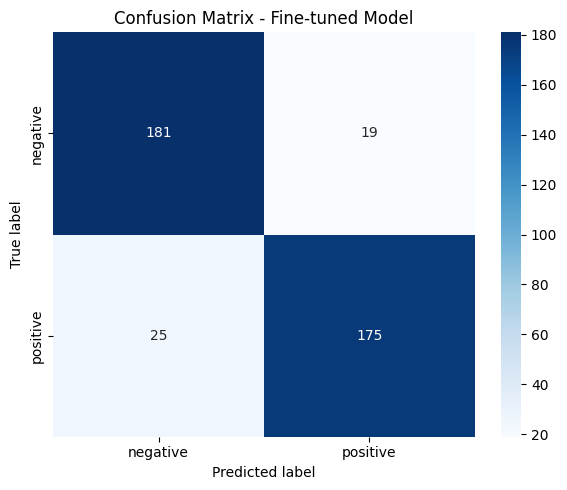

Fine-tuned confusion matrix
[[181  19]
 [ 25 175]]
Saved: C:\Users\User\Projects\transformers_overall_fix\outputs\comparison\confusion_matrix_fine_tuned.png


In [18]:
cm_ft_path = (
    comparison_dir
    / "confusion_matrix_fine_tuned.png"
)

cm_ft = save_confusion_matrix(
    validation_labels,
    y_pred_ft,
    title="Confusion Matrix - Fine-tuned Model",
    output_path=cm_ft_path,
)

print("Fine-tuned confusion matrix")
print(cm_ft)

print(
    "Saved:",
    cm_ft_path.resolve(),
)

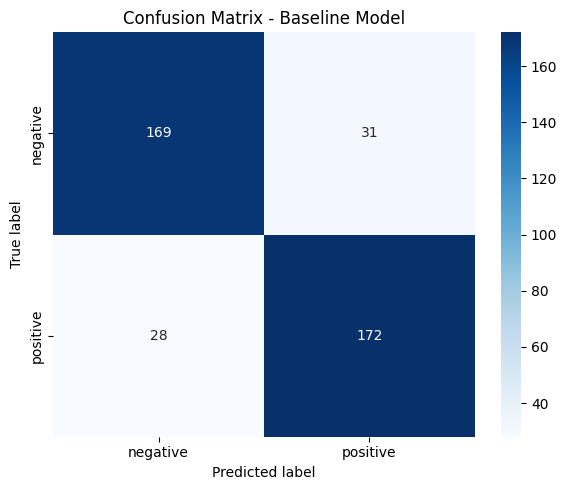

Baseline confusion matrix
[[169  31]
 [ 28 172]]
Saved: C:\Users\User\Projects\transformers_overall_fix\outputs\comparison\confusion_matrix_baseline.png


In [19]:
cm_base_path = (
    comparison_dir
    / "confusion_matrix_baseline.png"
)

cm_base = save_confusion_matrix(
    validation_labels,
    y_pred_base,
    title="Confusion Matrix - Baseline Model",
    output_path=cm_base_path,
)

print("Baseline confusion matrix")
print(cm_base)

print(
    "Saved:",
    cm_base_path.resolve(),
)

In [20]:
comparison_results_path = (
    comparison_dir
    / "comparison_results.txt"
)

comparison_results_text = f"""Transformers Day 6 - Model Comparison
=====================================

Fine-tuned Model
----------------
Accuracy: {acc_ft:.4f}
Macro F1: {f1_ft:.4f}

Classification report:
{report_ft}

Confusion matrix:
{cm_ft}

Baseline Model
--------------
Accuracy: {acc_base:.4f}
Macro F1: {f1_base:.4f}

Classification report:
{report_base}

Confusion matrix:
{cm_base}

Comparison
----------
Absolute F1 difference: {f1_difference:.4f}
Relative F1 improvement: {relative_f1_improvement:.2f}%
"""

comparison_results_path.write_text(
    comparison_results_text,
    encoding="utf-8",
)

print(comparison_results_text)

print(
    "Results saved:",
    comparison_results_path.resolve(),
)

Transformers Day 6 - Model Comparison

Fine-tuned Model
----------------
Accuracy: 0.8900
Macro F1: 0.8900

Classification report:
              precision    recall  f1-score   support

    negative     0.8786    0.9050    0.8916       200
    positive     0.9021    0.8750    0.8883       200

    accuracy                         0.8900       400
   macro avg     0.8904    0.8900    0.8900       400
weighted avg     0.8904    0.8900    0.8900       400


Confusion matrix:
[[181  19]
 [ 25 175]]

Baseline Model
--------------
Accuracy: 0.8525
Macro F1: 0.8525

Classification report:
              precision    recall  f1-score   support

    negative     0.8579    0.8450    0.8514       200
    positive     0.8473    0.8600    0.8536       200

    accuracy                         0.8525       400
   macro avg     0.8526    0.8525    0.8525       400
weighted avg     0.8526    0.8525    0.8525       400


Confusion matrix:
[[169  31]
 [ 28 172]]

Comparison
----------
Absolute F1 differe

### Итоги

Fine-tuned DistilBERT показал лучшее качество по сравнению с baseline моделью на одной и той же validation выборке из 400 объектов.

- Baseline Macro F1: 0.8525
- Fine-tuned Macro F1: 0.8900
- Абсолютное улучшение Macro F1: 0.0375
- Относительное улучшение Macro F1: 4.40%

Baseline допустил 59 ошибок, а fine-tuned модель 44 ошибки.

Основное улучшение связано с распознаванием negative класса количество negative примеров, ошибочно отнесённых к positive, снизилось с 31 до 19.